# Project 4 — Mini GPT

> **Transformer Mastery • Project Track**

This notebook is designed as an end-to-end, reproducible learning artifact: clear goals → implementation → experiments → diagnostics → conclusions.

In [1]:
import math, random, re, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError as e:
    raise ImportError("Install PyTorch first: pip install torch") from e

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


PyTorch: 2.11.0+cu128
Device: cuda


## 1. Mini-GPT: From Dataset to Generation

**Goal:** combine the previous ideas into a cleaner GPT-style training project with a small text corpus, validation split, checkpointing, perplexity, and controlled generation.

In [2]:
text = ("Transformers learn relationships between tokens through attention. Attention lets every position compare its query with keys and combine values. Autoregressive language models predict the next token from previous context. Small models are useful because every component can be inspected directly.  " * 500)

chars = sorted(set(text))
stoi  = {c:i for i,c in enumerate(chars)}
itos  = {i:c for c,i in stoi.items()}
ids   = torch.tensor([stoi[c] for c in text], dtype=torch.long)
cut   = int(0.9*len(ids))
train_ids, val_ids = ids[:cut], ids[cut:]
BLOCK=96; BATCH=48

def batch(split):
    src = train_ids if split=="train" else val_ids
    ix  = torch.randint(0, len(src)-BLOCK-1, (BATCH,))
    x   = torch.stack([src[i:i+BLOCK] for i in ix])
    y   = torch.stack([src[i+1:i+BLOCK+1] for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

print("vocab:", len(chars), "| train chars:", len(train_ids), "| val chars:", len(val_ids))


vocab: 29 | train chars: 134100 | val chars: 14900


In [3]:
class GPTBlock(nn.Module):
    def __init__(self, d_model=128, nhead=4, dropout=0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        T    = x.size(1)
        mask = torch.triu(torch.ones(T,T,device=x.device,dtype=torch.bool), diagonal=1)
        a,_  = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), attn_mask=mask, need_weights=False)
        x    = x + a
        x    = x + self.ff(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, vocab, d_model=128, layers=4, heads=4):
        super().__init__()
        self.token  = nn.Embedding(vocab,d_model)
        self.pos    = nn.Embedding(BLOCK,d_model)
        self.blocks = nn.ModuleList([GPTBlock(d_model,heads) for _ in range(layers)])
        self.ln     = nn.LayerNorm(d_model)
        self.head   = nn.Linear(d_model,vocab,bias=False)
        self.head.weight = self.token.weight

    def forward(self,x,y=None):
        T=x.size(1)
        p=torch.arange(T,device=x.device)
        h=self.token(x)+self.pos(p)[None]
        for b in self.blocks: h=b(h)
        logits=self.head(self.ln(h))
        loss=None
        if y is not None:
            loss=F.cross_entropy(logits.reshape(-1,logits.size(-1)),y.reshape(-1))
        return logits,loss

model=GPT(len(chars)).to(DEVICE)
optimizer=torch.optim.AdamW(model.parameters(),lr=2e-4,weight_decay=0.1)
print("parameters:",sum(p.numel() for p in model.parameters()))


parameters: 809344


In [4]:
@torch.no_grad()
def metrics():
    model.eval()
    result = {}
    for s in ["train","val"]:
        ls = []
        for _ in range(12):
            x,y   = batch(s); _,l=model(x,y); ls.append(l.item())
        result[s] = float(np.mean(ls))
    model.train()
    return result

history = []
best    = float("inf")
for step in range(1,1601):
    x,y = batch("train")
    optimizer.zero_grad(set_to_none=True)
    _,loss = model(x,y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
    optimizer.step()
    if step%100==0:
        m=metrics()
        history.append((step,m["train"],m["val"]))
        print(f"{step:4d} | train={m['train']:.3f} | val={m['val']:.3f} | val ppl={math.exp(m['val']):.1f}")
        if m["val"]<best:
            best=m["val"]
            torch.save({"model":model.state_dict(),"step":step,"val_loss":best},"mini_gpt_best.pt")


 100 | train=2.281 | val=2.271 | val ppl=9.7
 200 | train=1.884 | val=1.882 | val ppl=6.6
 300 | train=1.499 | val=1.496 | val ppl=4.5
 400 | train=0.845 | val=0.835 | val ppl=2.3
 500 | train=0.283 | val=0.286 | val ppl=1.3
 600 | train=0.108 | val=0.110 | val ppl=1.1
 700 | train=0.068 | val=0.070 | val ppl=1.1
 800 | train=0.058 | val=0.057 | val ppl=1.1
 900 | train=0.048 | val=0.049 | val ppl=1.0
1000 | train=0.046 | val=0.045 | val ppl=1.0
1100 | train=0.042 | val=0.042 | val ppl=1.0
1200 | train=0.039 | val=0.039 | val ppl=1.0
1300 | train=0.037 | val=0.037 | val ppl=1.0
1400 | train=0.037 | val=0.035 | val ppl=1.0
1500 | train=0.035 | val=0.035 | val ppl=1.0
1600 | train=0.035 | val=0.035 | val ppl=1.0


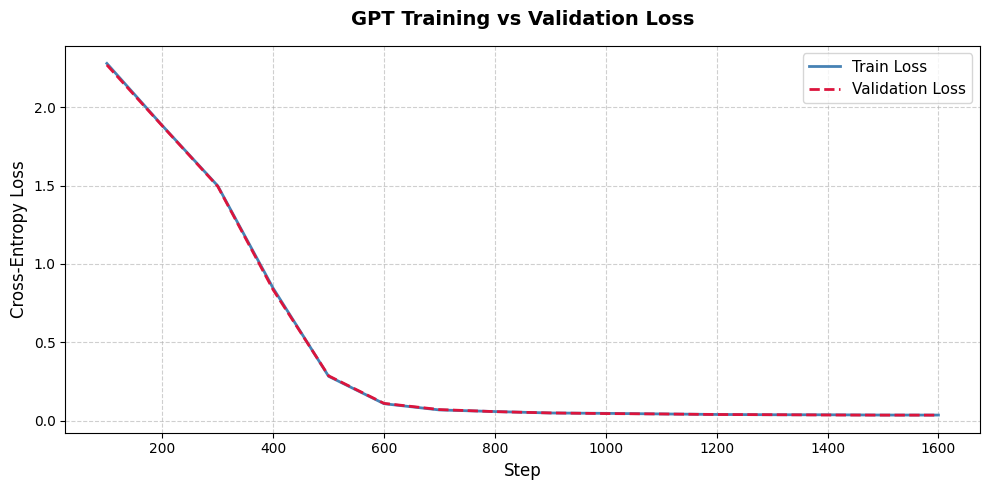

In [5]:
arr = np.array(history)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(arr[:,0], arr[:,1], label="Train Loss", color="steelblue", linewidth=2)
ax.plot(arr[:,0], arr[:,2], label="Validation Loss", color="crimson", linewidth=2, linestyle="--")

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("GPT Training vs Validation Loss", fontsize=14, fontweight="bold", pad=15)

ax.legend(fontsize=11, frameon=True)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [6]:
@torch.no_grad()
def generate(prompt, n=300, temperature=0.75, top_k=12):
    model.eval()
    x=torch.tensor([[stoi.get(c,0) for c in prompt][-BLOCK:]],device=DEVICE)
    for _ in range(n):
        logits,_=model(x[:,-BLOCK:])
        logits=logits[:,-1]/temperature
        vals,idx=torch.topk(logits,min(top_k,logits.size(-1)))
        probs=F.softmax(vals,-1)
        nxt=idx.gather(-1,torch.multinomial(probs,1))
        x=torch.cat([x,nxt],1)
    model.train()
    return "".join(itos[int(i)] for i in x[0])

print(generate("Transformers "))


Transformers learn relationships between tokens through attention. Attention lets every position compare its query with keys and combine values. Autoregressive language models predict the next token from previous context. Small models are useful because every component can be inspected directly.  Transformers le


## 2. Sanity Checks

A strong notebook should fail loudly when core assumptions break.

In [7]:
# Probability normalization check
x,y=batch("val")
logits,_=model(x,y)
probs=logits.softmax(-1)
assert torch.allclose(probs.sum(-1), torch.ones_like(probs.sum(-1)), atol=1e-5)

# Shape checks
assert logits.shape == (BATCH, BLOCK, len(chars))
print("✓ probability normalization")
print("✓ output shape")
print("✓ causal language-model pipeline is operational")


✓ probability normalization
✓ output shape
✓ causal language-model pipeline is operational
